## Users Dataset:

In this notebook, I explore the data related to users registered on the platform. It includes data loading, preprocessing, and analysis.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading:

In [2]:
# Read data
users = pd.read_csv('../data/raw/users.csv')

In [3]:
# Display the first 5 rows
users.head()

,UserID,City,State,Country,ZipCode,DegreeType,Major,GraduationDate,WorkHistoryCount,TotalYearsExperience,CurrentlyEmployed,ManagedOthers,ManagedHowMany,MajorCategoryID
0,23,Mount Prospect,IL,US,60056,High School,Not Applicable,2002-01-01 00:00:00,3,10.0,Yes,No,0,0.0
1,698,Normal,IL,US,61761,NaN,NaN,NaN,4,7.0,Yes,No,0,NaN
2,2305,Lake Forest,IL,US,60045,NaN,insurance,2010-12-01 00:00:00,4,9.0,Yes,No,0,180.0
3,2785,Chicago,IL,US,60607,Bachelor's,International Affairs,2005-01-01 00:00:00,6,10.0,Yes,No,0,191.0
4,3406,Joliet,IL,US,60435,Bachelor's,English,NaN,3,20.0,No,Yes,350,40.0


In [4]:
# Description of the dataset
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                1337 non-null   int64  
 1   City                  1337 non-null   object 
 2   State                 1337 non-null   object 
 3   Country               1337 non-null   object 
 4   ZipCode               1336 non-null   object 
 5   DegreeType            999 non-null    object 
 6   Major                 1028 non-null   object 
 7   GraduationDate        947 non-null    object 
 8   WorkHistoryCount      1337 non-null   int64  
 9   TotalYearsExperience  1296 non-null   float64
 10  CurrentlyEmployed     1152 non-null   object 
 11  ManagedOthers         1337 non-null   object 
 12  ManagedHowMany        1337 non-null   int64  
 13  MajorCategoryID       1029 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 146.4+ KB


Based on the observations above, I identified missing values, inconsistencies in formatting, and several data types that require modification.

## 2. Data Processing:

In [5]:
# Check duplicated values
duplicate_rows = users.duplicated().sum()
print(f"Duplicated rows: {duplicate_rows}")

duplicate_userid = users.duplicated(subset=['UserID']).sum()
print(f"Duplicated UserID rows: {duplicate_userid}")

Duplicated rows: 0
Duplicated UserID rows: 0


In [6]:
# Convert date to a proper format
users['GraduationDate'] = pd.to_datetime(users['GraduationDate'], errors='coerce')

In [7]:
# Convert ZipCode to integer values
users['ZipCode'] = pd.to_numeric(users['ZipCode'], errors='coerce')

In [8]:
# Check the missing values
users.isnull().sum()

UserID                    0
City                      0
State                     0
Country                   0
ZipCode                   4
DegreeType              338
Major                   309
GraduationDate          390
WorkHistoryCount          0
TotalYearsExperience     41
CurrentlyEmployed       185
ManagedOthers             0
ManagedHowMany            0
MajorCategoryID         308
dtype: int64

In [9]:
# Fill the missing values with Unknown
users['DegreeType'] = users['DegreeType'].fillna('Unknown')
users['Major'] = users['Major'].fillna('Unknown')
users['CurrentlyEmployed'] = users['CurrentlyEmployed'].fillna('Unknown')

In [10]:
# Fill the missing values with the median
users['ZipCode'] = users['ZipCode'].fillna(users['ZipCode'].median()).round().astype('Int64')
users['TotalYearsExperience'] = users['TotalYearsExperience'].fillna(users['TotalYearsExperience'].median())

In [11]:
# Fill the missing values with defined values
users['GraduationDate'] = users['GraduationDate'].fillna(pd.Timestamp('2000-01-01'))
users['MajorCategoryID'] = users['MajorCategoryID'].fillna(-1)

In [12]:
users.isnull().sum()

UserID                  0
City                    0
State                   0
Country                 0
ZipCode                 0
DegreeType              0
Major                   0
GraduationDate          0
WorkHistoryCount        0
TotalYearsExperience    0
CurrentlyEmployed       0
ManagedOthers           0
ManagedHowMany          0
MajorCategoryID         0
dtype: int64

In this stage, I confirmed that the dataset contains no duplicate records. However, missing values were detected in the ZipCode, GraduationDate, DegreeType, Major, CurrentEmployed,and TotalYearsExperience fields. These values were imputed using median-based or predefined replacement methods.

## 3. Data Cleaning:

In [13]:
# A function to clean the text
def clean_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
# Clean major and degreetype
users['Major'] = users['Major'].apply(clean_text)
users['Degree'] = users['DegreeType'].apply(clean_text)

In this section, I have applied data cleaning to Major and Degree columns to improve text quality and prepare the data for further analysis.

## 4. Data Analysis:

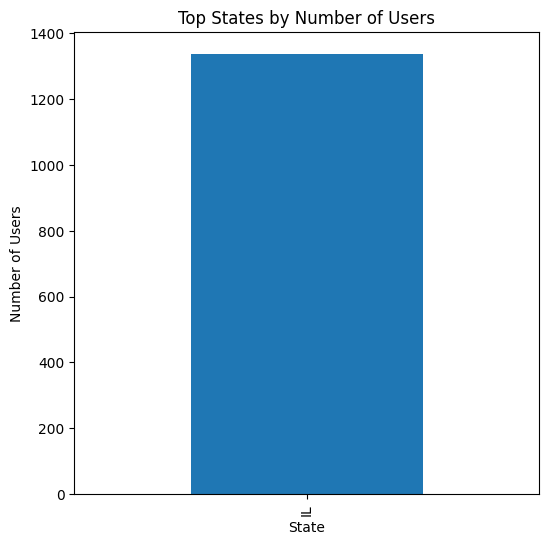

In [15]:
# Top states by number of users
plt.figure(figsize=(6, 6))
users['State'].value_counts().head(10).plot(kind='bar')
plt.title("Top States by Number of Users")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.show()

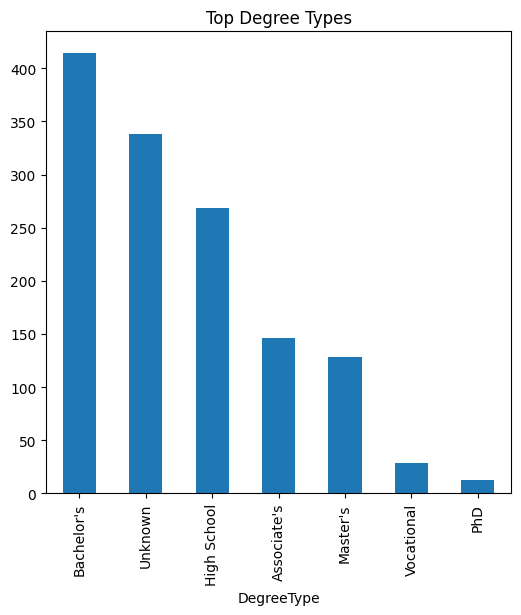

In [16]:
# Top degree types
plt.figure(figsize=(6, 6))
users['DegreeType'].value_counts().head(10).plot(kind='bar')
plt.title("Top Degree Types")
plt.show()

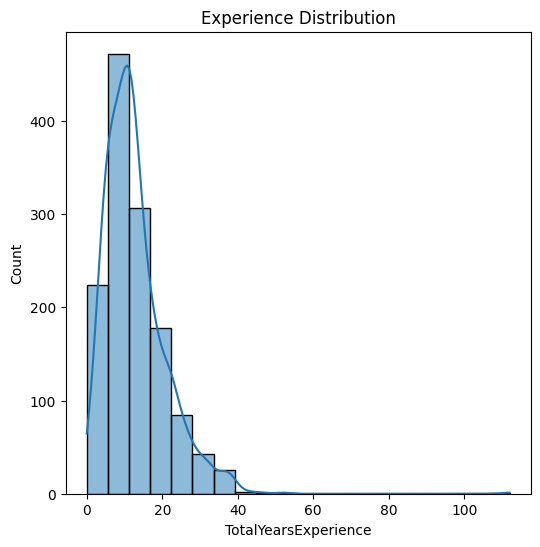

In [17]:
# Experience distribution
plt.figure(figsize=(6, 6))
sns.histplot(users['TotalYearsExperience'], bins=20, kde=True)
plt.title("Experience Distribution")
plt.show()

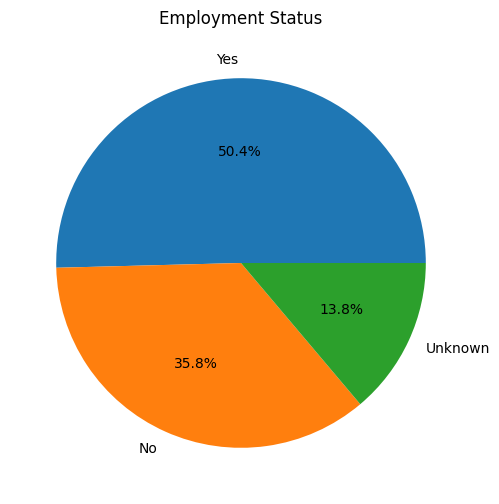

In [18]:
# Employment status
plt.figure(figsize=(6,6))
users['CurrentlyEmployed'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Employment Status")
plt.ylabel("")
plt.show()

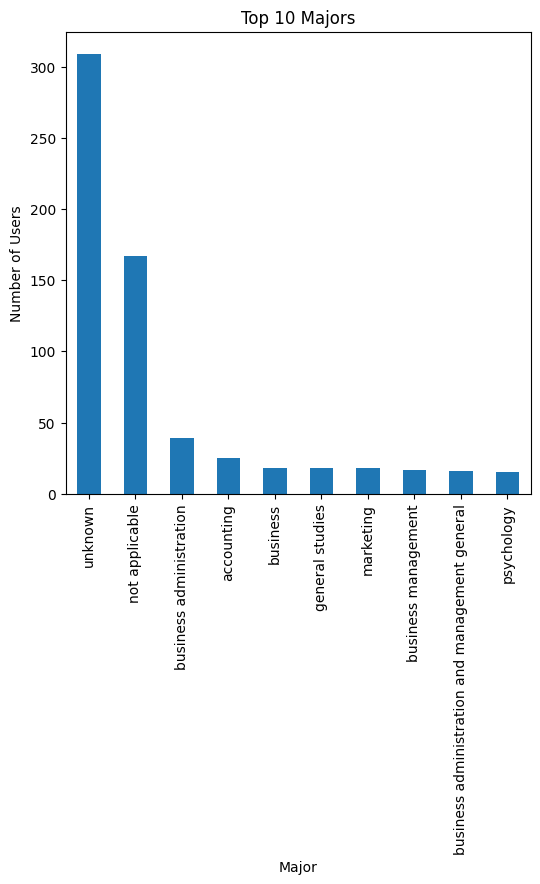

In [19]:
# Top 10 majors
plt.figure(figsize=(6, 6))
users['Major'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Majors")
plt.xlabel("Major")
plt.ylabel("Number of Users")
plt.show()

This section explores the demographic and educational characteristics of users on the platform. The visualizations highlight the states with the highest number of users, the most common degree types and majors, the distribution of years of experience, and the employment status of users.

## 5. Save Cleaned Dataset:

In [20]:
users.to_csv("../data/clean/users_cleaned.csv", index=False)